In [1]:
!python --version

Python 3.10.16


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import os
import time
import json
import random
from PIL import Image
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

In [2]:
import tensorflow as tf

In [3]:
devices = tf.config.experimental.list_physical_devices("GPU")
for device in devices:
    tf.config.experimental.set_memory_growth(device,enable=True)

In [8]:
annotation_folder = "./dataset/"
image_folder = "./dataset/images"

In [9]:
annotation_file = os.path.join(annotation_folder, "captions.txt")

In [10]:
annotation_file

'./dataset/captions.txt'

In [11]:
with open(annotation_file, "r") as file:
    annotations = file.read()
    file.close()

In [12]:
annotations.split(".")[0]

'image_name|caption_number|caption_text\n1000268201_693b08cb0e'

In [19]:
annotations.split("\n")[1:4]

['1000268201_693b08cb0e.jpg|0|A child in a pink dress is climbing up a set of stairs in an entry way .',
 '1000268201_693b08cb0e.jpg|1|A girl going into a wooden building .',
 '1000268201_693b08cb0e.jpg|2|A little girl climbing into a wooden playhouse .']

In [14]:
image_path_to_caption = collections.defaultdict(list)

In [20]:
for line in annotations.split("\n"):
    image_name = line.split("|")[0]
    caption = line.split("\t")[-1]
    caption = f"<start> {caption} <end>"
    image_path = os.path.join(image_folder, image_name)
    if image_path.endswith(".jpg"):
        image_path_to_caption[image_path].append(caption)

### Each Image is having 5 captions

In [22]:
image_path_to_caption[os.path.join(image_folder, "1000268201_693b08cb0e.jpg")]

['<start> 1000268201_693b08cb0e.jpg|0|A child in a pink dress is climbing up a set of stairs in an entry way . <end>',
 '<start> 1000268201_693b08cb0e.jpg|1|A girl going into a wooden building . <end>',
 '<start> 1000268201_693b08cb0e.jpg|2|A little girl climbing into a wooden playhouse . <end>',
 '<start> 1000268201_693b08cb0e.jpg|3|A little girl climbing the stairs to her playhouse . <end>',
 '<start> 1000268201_693b08cb0e.jpg|4|A little girl in a pink dress going into a wooden cabin . <end>']

In [23]:
len(image_path_to_caption)

8091

In [24]:
train_image_paths = list(image_path_to_caption.keys())
random.shuffle(train_image_paths)
print(len(train_image_paths))

8091


In [60]:
train_image_paths[0]

'./dataset/images\\3462512074_2b4db1ffd6.jpg'

In [29]:
train_captions = []
image_name_vector = []

for image_path in train_image_paths:
    caption_list = image_path_to_caption[image_path]
    train_captions.extend(caption_list)
    image_name_vector.extend([image_path]*len(caption_list))

In [31]:
print(train_captions[0])

<start> 3462512074_2b4db1ffd6.jpg|0|a man on a harness in the middle of climbing through a cave . <end>


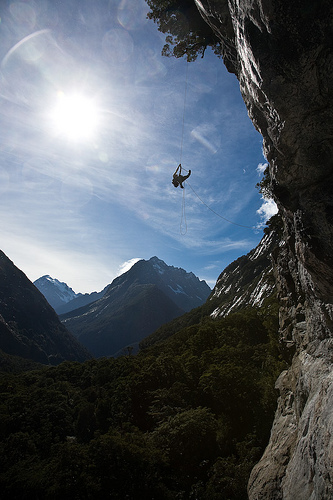

In [32]:
Image.open(image_name_vector[0])

In [34]:
def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299,299))
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, image_path

In [35]:
image_model = tf.keras.applications.InceptionV3(include_top=False, weights="imagenet")
new_input = image_model.input
hidden_layer = image_model.layers[-1].output

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step 


In [36]:
image_features_extract_model = tf.keras.Model(new_input, hidden_layer)

In [38]:
encode_train = sorted(set(image_name_vector))

In [39]:
image_dataset = tf.data.Dataset.from_tensor_slices(encode_train)
image_dataset = image_dataset.map(load_image).batch(32)

In [41]:
for img, path in tqdm(image_dataset):
    batch_features = image_features_extract_model(img)
    batch_features = tf.reshape(batch_features, (batch_features.shape[0],-1,batch_features.shape[3]))
    for bf, p in zip(batch_features, path):
        path_of_features = p.numpy().decode("utf-8")
        np.save(path_of_features, bf.numpy())

100%|████████████████████████████████████████████████████████████████████████████████| 253/253 [09:30<00:00,  2.26s/it]


In [42]:
def calc_max_length(tensor):
    return max(len(t) for t in tensor)

In [43]:
top_k = 5000
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=top_k, oov_token="<unk>", 
            filters='!"#$%&()*+.,-/:;=?@[\]^_`{|}~')
tokenizer.fit_on_texts(train_captions)

In [44]:
train_seqs = tokenizer.texts_to_sequences(train_captions)

In [48]:
capt_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding="post")

In [47]:
max_length = calc_max_length(train_seqs)
max_length

43

In [77]:
img_to_capt_vector = collections.defaultdict(list)
for img, capt in zip(image_name_vector, capt_vector):
    img_to_capt_vector[img].append(capt)

In [78]:
img_keys = list(img_to_capt_vector.keys())
random.shuffle(img_keys)

In [79]:
slice_index = int(len(img_keys)*0.8)
img_name_train_keys, img_name_test_keys = img_keys[:slice_index], img_keys[slice_index:]

In [81]:
img_name_train_keys = [name.replace("\\","/") for name in img_name_train_keys]
img_name_test_keys = [name.replace("\\","/") for name in img_name_test_keys]

In [82]:
img_name_train_keys[0]

'./dataset/images/2957071266_1b40ec7d96.jpg'

In [83]:
img_name_test_keys[0]

'./dataset/images/3683592946_262e9bfbfd.jpg'

In [92]:
img_to_capt_vector_dict = {str(key).replace("\\","/"): val for key, val in dict(img_to_capt_vector).items()}

In [94]:
img_name_train = []
capt_train = []
for img_train in img_name_train_keys:
    capt_train_len = len(img_to_capt_vector_dict[img_train])
    img_name_train.extend([img_train]*capt_train_len)
    capt_train.extend(img_to_capt_vector_dict[img_train])

In [95]:
img_name_test = []
capt_test = []
for img_test in img_name_test_keys:
    capt_test_len = len(img_to_capt_vector_dict[img_test])
    img_name_test.extend([img_test]*capt_test_len)
    capt_test.extend(img_to_capt_vector_dict[img_test])

In [96]:
len(img_name_train)

32355

In [100]:
len(img_name_test)

8095

In [98]:
len(capt_train)

32355

In [99]:
len(capt_test)

8095

In [101]:
batch_size = 16
buffer_size = 500
embedding_dim = 256
units = 512
vocab_size = top_k + 1
num_steps = len(img_name_train)
feature_shape = 2048
attention_features_shape = 16

In [102]:
def map_func(image_name, capt):
    img_tensor = np.load(image_name.decode("utf-8")+".npy")
    return img_tensor, capt

In [103]:
dataset = tf.data.Dataset.from_tensor_slices((img_name_train, capt_train))

In [104]:
dataset = dataset.map(lambda item1, item2: tf.numpy_function(map_func, [item1,item2],[tf.float32,tf.int32]))

In [105]:
dataset = dataset.shuffle(buffer_size).batch(batch_size)

In [106]:
class BahdanauAttention(tf.keras.Model):
    def __init__(self,units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, features, hidden):
        hidden_with_time_axis = tf.expand_dims(hidden,1)
        attention_hidden_layer = (tf.nn.tanh(self.W1(features)+self.W2(hidden_with_time_axis)))
        score = self.V(attention_hidden_layer)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

In [107]:
class CNN_Encoder(tf.keras.Model):
    def __init__(self, embedding_dim):
        super(CNN_Encoder, self).__init__()
        self.fc = tf.keras.layers.Dense(embedding_dim)

    def call(self, x):
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

In [108]:
class RNN_Decoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size):
        super(RNN_Decoder, self).__init__()
        self.units = units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.units, return_sequences=True, return_state=True,recurrent_initializer='glorot_uniform')
        self.fc1 = tf.keras.layers.Dense(self.units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(self.units)

    def call(self, x, features, hidden):
        context_vector, attention_weights = self.attention(features, hidden)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1),x], axis=-1)
        output, state = self.gru(x)
        x = self.fc1(output)
        x = tf.reshape(x, (-1, x.shape[2]))
        x = self.fc2(x)
        return x, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))
    

In [109]:
encoder = CNN_Encoder(embedding_dim)
decoder = RNN_Decoder(embedding_dim, units, vocab_size)

In [110]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

In [111]:
def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real,0))
    loss_ = loss_object(real,pred)
    mask = tf.cast(mask, dtype = loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)

In [113]:
checkpoint_path = "./checkpoints/train"
ckpt = tf.train.Checkpoint(encoder=encoder,decoder=decoder,optimizer=optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

In [114]:
loss_plot = []

In [116]:
@tf.function
def train_step(img_tensor, target):
    loss = 0
    hidden = decoder.reset_state(batch_size=target.shape[0])
    dec_input = tf.expand_dims([tokenizer.word_index["<start>"]]*target.shape[0],1)
    with tf.GradientTape() as tape:
        features = encoder(img_tensor)
        for i in range(1, target.shape[1]):
            prediction, hidden, _ = decoder(dec_input, features, hidden)
            loss += loss_function(target[:,i], prediction)
            dec_input = tf.expand_dims(target[:,i],1)
    total_loss = (loss/int(target.shape[1]))
    trainable_variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, trainable_variables)
    optimizer.apply_gradients(zip(gradients, trainable_variables))
    return loss, total_loss

In [ ]:
epochs = 20
start_epoch = 0
for epoch in range(start_epoch, epochs):
    start = time.time()
    total_loss = 0

    for (batch, (img_tensor, target)) in enumerate(dataset):
        batch_loss, t_loss = train_step(img_tensor, target)
        total_loss += t_loss

        if batch % 100 == 0:
            average_batch_loss = batch_loss.numpy() / int(target.shape[1])
            print(f"Epoch {epoch + 1} Batch {batch} Loss {average_batch_loss:.4f}")
        loss_plot.append(total_loss/num_steps)
    if epoch % 5 == 0:
        ckpt_manager.save()
    print(f"Epoch {epoch + 1} Loss {total_loss/num_steps:.6f}")
    print(f"Time taken for 1 epoch {time.time() - start:.2f} sec\n")

Epoch 1 Batch 0 Loss 2.8492
Epoch 1 Batch 100 Loss 1.5501
Epoch 1 Batch 200 Loss 1.5021
Epoch 1 Batch 300 Loss 1.2648
Epoch 1 Batch 400 Loss 1.0283
Epoch 1 Batch 500 Loss 1.4126
Epoch 1 Batch 600 Loss 1.1240
Epoch 1 Batch 700 Loss 1.0475
Epoch 1 Batch 800 Loss 1.0460
Epoch 1 Batch 900 Loss 1.1669
Epoch 1 Batch 1000 Loss 1.1515
Epoch 1 Batch 1100 Loss 1.1690
Epoch 1 Batch 1200 Loss 0.9334


In [ ]:
def evaluate(image):
    attention_plot = np.zeros((max_length, attention_features_shape))
    hidden = decoder.reset_state(batch_size = 1)
    temp_input = tf.expand_dims(load_image(image)[0],0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))
    features = encoder(img_tensor_val)
    dec_input = tf.expand_dims([tokenizer.word_index["<start>"]],0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = decoder(dec_input, features, hidden)
        attention_plot[i] = tf.reshape(attention_weights, (-1,)).numpy()
        predicted_id = tf.argmax(predictions[0]).numpy()
        result.append(tokenizer.index_word[predixted_id])
        if tokenizer.index_word[predicted_id] == "<end>":
            return result, attention_plot
        dec_input = tf.expand_dims([predicted_id],0)
    attention_plot = attention_plot[:len(result),:]
    return result, attention_plot

In [ ]:
def plot_attention(image, result, attention_plot):
    temp_image = np.array(Image.open(image))
    fig = plt.figure(figsize = (10,10))
    len_result = len(result)
    for i in range(len_result):
        temp_att = np.resize(attention_plot[i],(8,8))
        grid_size = max(int(np.ceil(len_result/2)),2)
        ax = fig.add_subplot(grid_size, grid_size, i+1)
        ax.set_title(result[i])
        img = ax.imshow(temp_image)
        ax.imshow(temp_att, cmap="gray", alpha=0.4, extebt=img.get_extent())
    plt.tight_layout()
    plt.show()

In [ ]:
rid = np.random.randint(0, len(img_name_val))
image = img_name_val[rid]
real_caption = ' '.join([tokenizer.index_word[i] for i in cap_val[rid] id i not in [0]])
result, attention_plot = evaluate(image)
print("Real Caption:", real_caption)
print("Prediction Caption:", " ".join(result))
plot_attention(image, result, attention_plot)
Image.open(img_name_val[rid])